In [1]:
from sklearn.neural_network import MLPClassifier
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [5]:
pipeline_raw = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", MLPClassifier()),
    ]
)

c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Модель MLPClassifier
F1-macro: 0.748 ± 0.009
F1-weighted: 0.817 ± 0.005


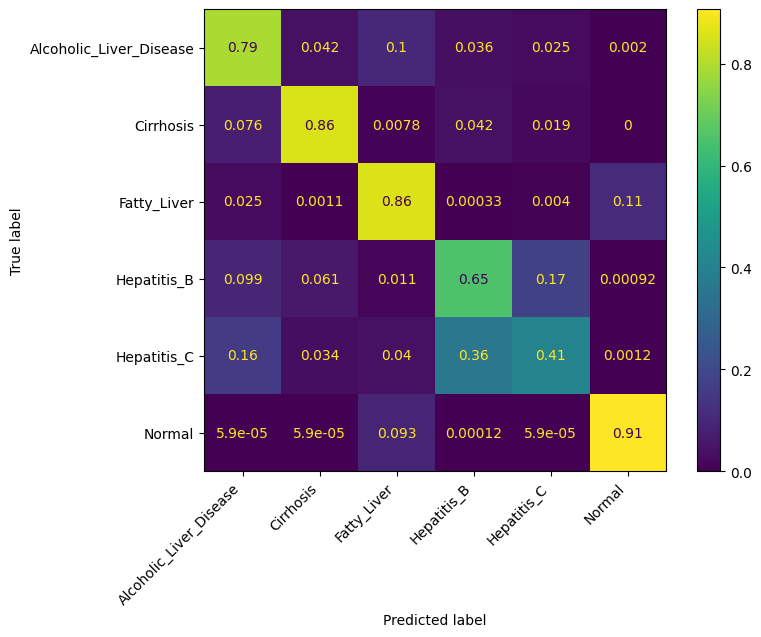

In [6]:
evaluate_pipeline(pipeline_raw, X, y)

Без масштабирования MLP имеет низкую точность из-за проблем сходимости градиентного спуска на признаках разного масштаба (прыгает по большим признакам и плохо двигается по маленьким)

In [7]:
pipeline_scaled = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric)
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", MLPClassifier()),
    ]
)

c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Yanovich\Documents\Projects\Cats\table_analysis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum itera

Модель MLPClassifier
F1-macro: 0.758 ± 0.006
F1-weighted: 0.828 ± 0.003


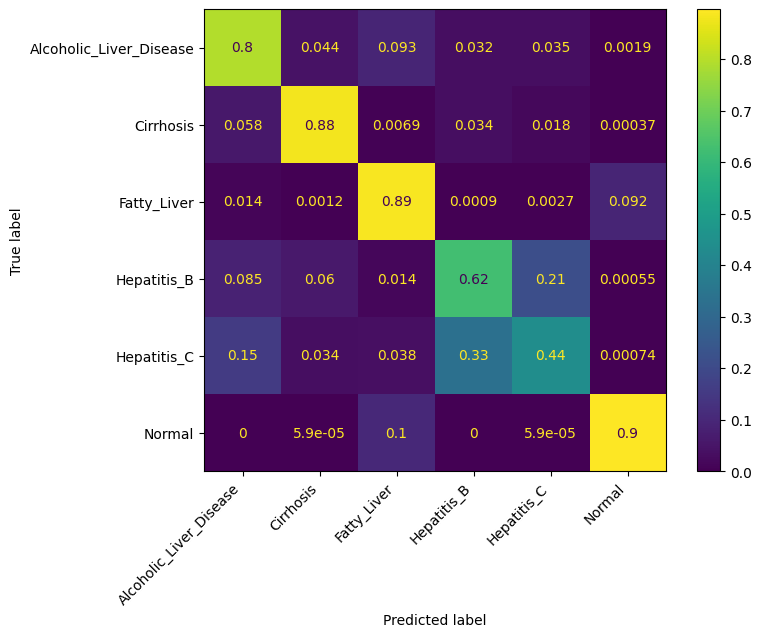

In [8]:
evaluate_pipeline(pipeline_scaled, X, y)

Масштабирование увеличило точность MLP

In [9]:
pipeline_tuned = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric),
                ],
                remainder="passthrough",
            ),
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                batch_size="auto",
                learning_rate="adaptive",
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

Модель MLPClassifier
F1-macro: 0.764 ± 0.003
F1-weighted: 0.828 ± 0.003


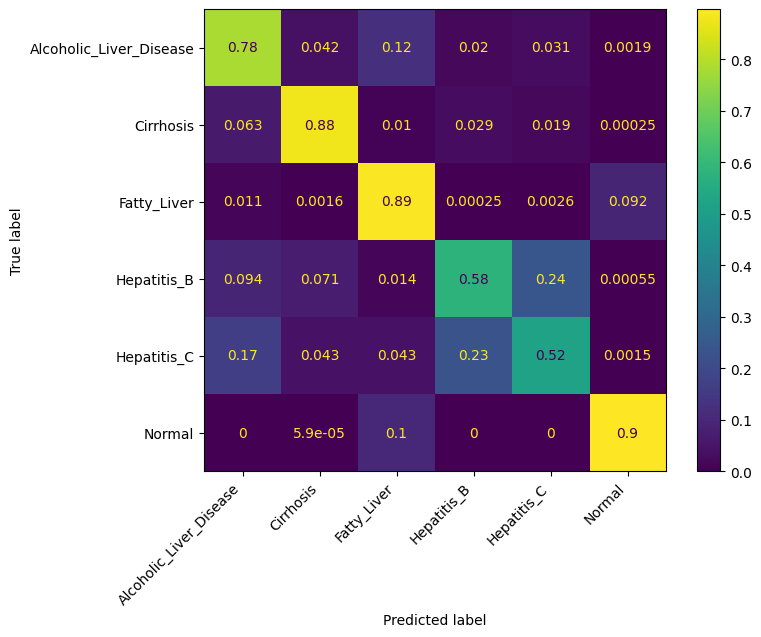

In [10]:
evaluate_pipeline(pipeline_tuned, X, y)

Небольшой тюнинг гиперпараметров позволил модели сойтись быстрее и в более лучшее решение